In [1]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("aryashah2k/soybean-seedsclassification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 610M/610M [00:05<00:00, 127MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1):
['Spotted soybeans', 'Intact soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Broken soybeans']


In [4]:
import os

# Use 'path' directly as classes are located here
data_path = path

# List soybean class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Soybean classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Soybean classes found: ['Spotted soybeans', 'Intact soybeans', 'Immature soybeans', 'Skin-damaged soybeans', 'Broken soybeans']



--- Displaying Sample Images from Dataset (/root/.cache/kagglehub/datasets/aryashah2k/soybean-seedsclassification-dataset/versions/1) ---
Found 5513 images. Displaying 6 sample images:


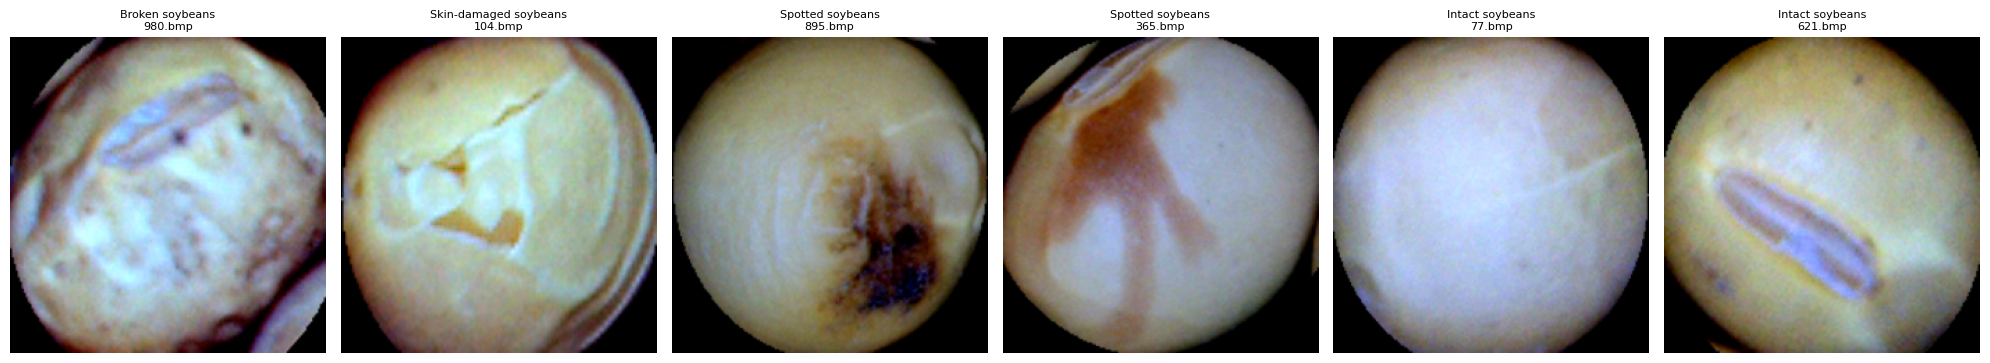

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct path identified in the previous cell
data_path = path
print(f"\n--- Displaying Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [6]:
!pip install split-folders

In [7]:
import splitfolders

# Define the output folder
output_folder = "soybean_split"

# Split with a ratio of 0.8 for train and 0.2 for val (test)
# seed=1337 ensures reproducibility
splitfolders.ratio(data_path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Dataset successfully split! Check the '{output_folder}' directory.")

Copying files: 5513 files [00:16, 332.24 files/s]

Dataset successfully split! Check the 'soybean_split' directory.


In [8]:
# Verify the split results
for split in ['train', 'val']:
    print(f"\n--- {split.upper()} set ---")
    split_path = os.path.join(output_folder, split)
    for class_name in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, class_name)))
        print(f"{class_name}: {count} images")


--- TRAIN set ---
Spotted soybeans: 846 images
Intact soybeans: 960 images
Immature soybeans: 900 images
Skin-damaged soybeans: 901 images
Broken soybeans: 801 images

--- VAL set ---
Spotted soybeans: 212 images
Intact soybeans: 241 images
Immature soybeans: 225 images
Skin-damaged soybeans: 226 images
Broken soybeans: 201 images


In [9]:
import tensorflow as tf

# Check for GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Setting memory growth to avoid allocating all memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU is NOT available. Using CPU instead.")

GPU is NOT available. Using CPU instead.


In [10]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(classes)

# Data Preparation (Generators)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Model Construction (MobileNet)
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training
print("Starting training...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Found 4408 images belonging to 5 classes.
Found 1105 images belonging to 5 classes.
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting training...
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.6525 - loss: 0.8751 - val_accuracy: 0.7584 - val_loss: 0.6249
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.7391 - loss: 0.6526 - val_accuracy: 0.7457 - val_loss: 0.6520
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.7632 - loss: 0.6180 - val_accuracy: 0.8000 - val_loss: 0.5075
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.7809 - loss: 0.5794 - val_accuracy: 0.7937 - val_loss: 0.5267
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.7985 - loss: 0.5278 - val_accuracy: 0.7973 - val_loss: 0.5134
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.7999 - loss: 0.5159 - val_accuracy: 0.8045 - val_loss: 0.5256
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.812

In [11]:
# Summarize training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("--- Training Summary ---")
print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy:   0.8319
Final Validation Accuracy: 0.8362
Final Training Loss:       0.4369
Final Validation Loss:     0.4235


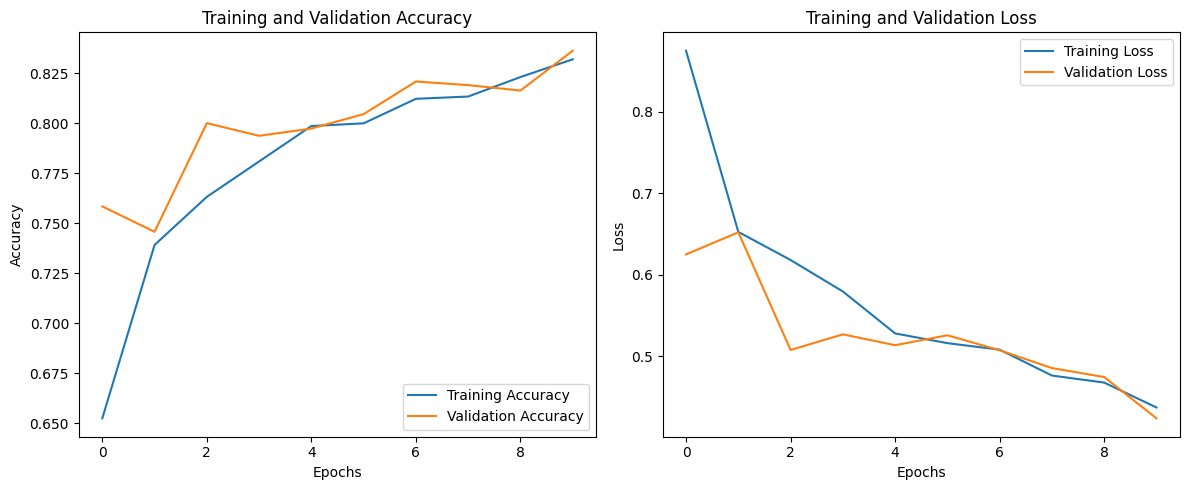

In [12]:
import matplotlib.pyplot as plt

# Plot Training and Validation Charts
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Chart
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Chart
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()